In [1]:
import os
import numpy as np
from spectral.io import envi
from spectral.io.envi import read_envi_header
import matplotlib.pyplot as plt
from pyproj import Transformer
from glob import glob
import pickle
from pyproj import Transformer
import rasterio

In [2]:
os.chdir('/store/carroll/col/data/2025/')

wavelengths = np.loadtxt('/store/carroll/col/data/wavelengths_neon.txt')[:,1]*1000 # nm
wl_nan = np.loadtxt('/store/carroll/col/data/wl_nan.txt')

In [28]:
with open('/store/carroll/repos/chess-isofit/1_rccs/2025/rcc_subsets_2025_fids.txt') as f:
    fids = [x.strip() for x in f.readlines()]

In [9]:
# subset imagery for apply_oe retrievals
output_dir = 'rccs/subsets_tmp/'
buf = 150

# get targets in utm 13n coords
transformer = Transformer.from_crs('EPSG:4326', 'EPSG:32613')
snodgrass_insitu = transformer.transform(38.9181643,-106.9596351)
matterhorn_lot = transformer.transform(38.90306764650836, -106.96917819931046)
airpark = transformer.transform(38.85485376230754, -106.93336548979009)
coal_creek = transformer.transform(38.857671227274096, -107.09512257147314)
almo = transformer.transform(38.712222, -106.792222)
upta = transformer.transform(38.947500, -106.616667)

In [ ]:
for fid in fids:
    for x, y in [matterhorn_lot, airpark, coal_creek, snodgrass_insitu, almo, upta]:
        fid_ = '_'.join(fid.split('_')[0:3])
        site_ = '_'.join(fid.split('_')[3:])
        print(fid_, site_)
        
        # translate x, y to image coordinates
        fp_loc = glob(f'raw/L1/radianceENVI/{fid_}_IGM_Data.hdr')[0]
        loc = envi.open(fp_loc).open_memmap()
        rows, cols = loc[...,0].shape
        flat_x = loc[...,0].flatten()
        flat_y = loc[...,1].flatten()
        diff = np.abs(flat_x - x) + np.abs(flat_y - y)
        if np.min(diff) > 2: # check if target in fid
            print('skip')
            continue
        idx = np.argmin(diff)
        row, col = np.unravel_index(idx, (rows, cols))
    
        # rdn
        fp_rdn = glob(f'raw/L1/radianceENVI/{fid_}_*rdn.hdr')[0]
        fp_out = os.path.join(output_dir, f'{fid_}_{site_}_rdn.hdr')
        meta = envi.open(fp_rdn).metadata
        meta['lines'] = buf*2
        meta['samples'] = buf*2
        out_ds = envi.create_image(fp_out, meta, ext='', force=True)
        out_ds.open_memmap(writable=True)[:,:,:] = envi.open(fp_rdn).open_memmap()[row-buf:row+buf, col-buf:col+buf, :]
    
        # obs
        fp_obs = glob(f'raw/L1/radianceENVI/{fid}_*OBS_Data.hdr')[0]
        fp_out = os.path.join(output_dir, f'{fid_}_{site_}_obs.hdr')
        meta = envi.open(fp_obs).metadata
        meta['lines'] = buf*2
        meta['samples'] = buf*2
        out_ds = envi.create_image(fp_out, meta, ext='', force=True)
        out_ds.open_memmap(writable=True)[:,:,:] = envi.open(fp_obs).open_memmap()[row-buf:row+buf, col-buf:col+buf, :]
    
        # loc
        fp_out = os.path.join(output_dir, f'{fid_}_{site_}_loc.hdr')
        meta = envi.open(fp_loc).metadata
        meta['lines'] = buf*2
        meta['samples'] = buf*2
        out_ds = envi.create_image(fp_out, meta, ext='', force=True)
        out_ds.open_memmap(writable=True)[:,:,:] = envi.open(fp_loc).open_memmap()[row-buf:row+buf, col-buf:col+buf, :]

In [ ]:
# prepare representative single px
# extract the rdn, obs, loc data for each target
# dict: single_px[flightline][bright/dark][rdn/obs/loc]

In [34]:
fps

['rccs/subsets/NIS01_20250614_175924_almo_rdn.hdr',
 'rccs/subsets/NIS01_20250626_165802_airpark_rdn.hdr',
 'rccs/subsets/NIS01_20250626_174116_snodgrass_busstop_insitu_rdn.hdr',
 'rccs/subsets/NIS01_20250627_155921_matterhorn_lot_rdn.hdr',
 'rccs/subsets/NIS01_20250628_160551_airpark_rdn.hdr',
 'rccs/subsets/NIS01_20250628_165939_snodgrass_busstop_insitu_rdn.hdr',
 'rccs/subsets/NIS01_20250628_170927_snodgrass_busstop_insitu_rdn.hdr',
 'rccs/subsets/NIS01_20250628_172359_snodgrass_busstop_insitu_rdn.hdr',
 'rccs/subsets/NIS01_20250628_174221_matterhorn_lot_rdn.hdr',
 'rccs/subsets/NIS01_20250629_150841_matterhorn_lot_rdn.hdr',
 'rccs/subsets/NIS01_20250702_162359_coal_creek_rdn.hdr',
 'rccs/subsets/NIS01_20250709_164959_upta_rdn.hdr',
 'rccs/subsets/NIS01_20250709_165959_upta_rdn.hdr']

In [ ]:
# set up target bboxes
fps = glob('rccs/subsets/*_rdn.hdr')
flights = [x.split('/')[-1].strip('_rdn.hdr') for x in fps]
targets = ['dark', 'bright', 'insitu']
bboxes = {k1: {} for k1 in flights}

bboxes['NIS01_20250626_165802_airpark']['dark'] = [150, 160, 165, 175]
bboxes['NIS01_20250626_165802_airpark']['bright'] = [145, 147, 143, 147] # same as in situ

bboxes['NIS01_20250628_160551_airpark']['dark'] = [150, 160, 165, 175]
bboxes['NIS01_20250628_160551_airpark']['bright'] = [145, 147, 143, 147] # same as in situ

bboxes['NIS01_20250626_174116_snodgrass_busstop_insitu']['insitu'] = [148, 153, 148, 152]
bboxes['NIS01_20250628_165939_snodgrass_busstop_insitu']['insitu'] = [146, 151, 150, 153]
bboxes['NIS01_20250628_170927_snodgrass_busstop_insitu']['insitu'] = [146, 151, 147, 151]
bboxes['NIS01_20250628_172359_snodgrass_busstop_insitu']['insitu'] = [146, 151, 148, 152]

bboxes['NIS01_20250628_174221_matterhorn_lot']['bright'] = [250, 255, 175, 180]
bboxes['NIS01_20250628_174221_matterhorn_lot']['insitu'] = [99, 103, 146, 150]

bboxes['NIS01_20250629_150841_matterhorn_lot']['bright'] = [250, 255, 175, 180]
bboxes['NIS01_20250629_150841_matterhorn_lot']['insitu'] = [99, 103, 146, 150]

bboxes['NIS01_20250627_155921_matterhorn_lot']['bright'] = [250, 255, 175, 180]
bboxes['NIS01_20250627_155921_matterhorn_lot']['insitu'] = [99, 101, 146, 152]

bboxes['NIS01_20250702_162359_coal_creek']['dark'] = [213, 216, 33, 34]
bboxes['NIS01_20250702_162359_coal_creek']['bright'] = [100, 105, 60, 65]

bboxes['NIS01_20250614_177824_almo']['dark'] = [248, 252, 142, 147]
bboxes['NIS01_20250614_177824_almo']['bright'] = [239, 243, 401, 403]

bboxes['NIS01_20250709_164963_upta']['bright'] = [293, 303, 275, 282]
bboxes['NIS01_20250709_166260_upta']['bright'] = [293, 303, 275, 282]

In [66]:
px = {}
for flight in bboxes.keys():
    px[flight]={}
    for k in bboxes[flight].keys():
        px[flight][k]={}

In [ ]:
output_dir = 'rccs/subsets'

for site in ['airpark', 'busstop', 'lot', 'upta']:
    site_flights = [x for x in flights if site in x]
    n = len(site_flights)
    fig, axs = plt.subplots(ncols=n, figsize=(5*n, 5))
    for i in range(n):
        flight = site_flights[i]
        targets = bboxes[flight].keys()
        for k in targets:
            row1, row2, col1, col2 = bboxes[flight][k]
            fp = glob(os.path.join(output_dir, f'{flight}_rdn.hdr'))[0]
            px[flight][k]['rdn'] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[row1:row2, col1:col2, :], axis=(0,1))
            fp = glob(os.path.join(output_dir, f'{flight}_obs.hdr'))[0]
            px[flight][k]['obs'] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[row1:row2, col1:col2, :], axis=(0,1))
            fp = glob(os.path.join(output_dir, f'{flight}_loc.hdr'))[0]
            px[flight][k]['loc'] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[row1:row2, col1:col2, :], axis=(0,1))
               
        fp = glob(os.path.join(output_dir, f'{flight}_rdn.hdr'))[0]
        wl = [float(x) for x in read_envi_header(fp)['wavelength']]
        rgb = envi.open(fp).open_memmap(interleave='bip')[:,:,np.array([60,40,30])].copy()
        axs[i].imshow(rgb / np.max(rgb, axis=(0, 1))*2)
        for k, (row1, row2, col1, col2) in bboxes[flight].items():
            x = [col1, col2, col2, col1, col1]
            y = [row1, row1, row2, row2, row1]
            axs[i].plot(x, y, label=k)
        axs[i].legend()
        axs[i].set_title(flight)
    plt.show()

for site in ['coal_creek', 'almo']: # separated just because ax fails with only 1 subplot
    flight = [x for x in flights if site in x][0]
    targets = bboxes[flight].keys()
    for k in targets:
        row1, row2, col1, col2 = bboxes[flight][k]
        fp = glob(os.path.join(output_dir, f'{flight}_rdn.hdr'))[0]
        px[flight][k]['rdn'] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[row1:row2, col1:col2, :], axis=(0,1))
        fp = glob(os.path.join(output_dir, f'{flight}_obs.hdr'))[0]
        px[flight][k]['obs'] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[row1:row2, col1:col2, :], axis=(0,1))
        fp = glob(os.path.join(output_dir, f'{flight}_loc.hdr'))[0]
        px[flight][k]['loc'] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[row1:row2, col1:col2, :], axis=(0,1))
        fp = glob(os.path.join(output_dir, f'{flight}_rdn.hdr'))[0]
        rgb = envi.open(fp).open_memmap(interleave='bip')[:,:,np.array([60,40,30])].copy()
    fig = plt.figure()
    plt.imshow(rgb / np.max(rgb, axis=(0, 1))*2)
    for k, (row1, row2, col1, col2) in bboxes[flight].items():
        x = [col1, col2, col2, col1, col1]
        y = [row1, row1, row2, row2, row1]
        plt.plot(x, y, label=k)
    plt.legend()
    plt.title(flight)
    plt.show()


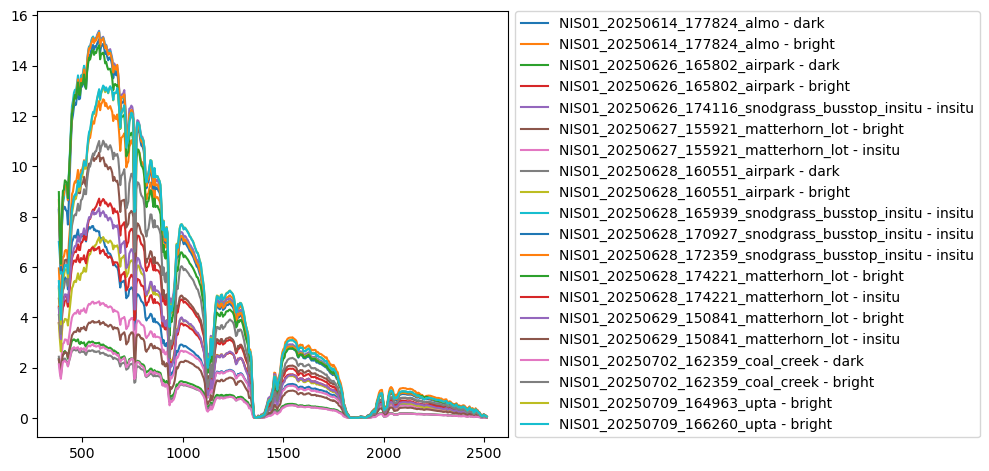

In [41]:
# plot radiance
flights = px.keys()

fig = plt.figure(figsize=(10,5))

for f in flights:
    targets = px[f].keys()
    for k in targets:
        plt.plot(wl, px[f][k]['rdn'], label=f'{f} - {k}')
        
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

plt.show()

In [69]:
# export
fp_out = os.path.join('rccs', 'single_pxs.pkl')
with open(fp_out, 'wb') as f:
    pickle.dump(px, f)

fp_out = os.path.join('rccs', 'single_pxs_bboxes.pkl')
with open(fp_out, 'wb') as f:
    pickle.dump(bboxes, f)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.008045167827382977..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-923.4452014373938..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.007091642614785869..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.003947937620314494..2.0].


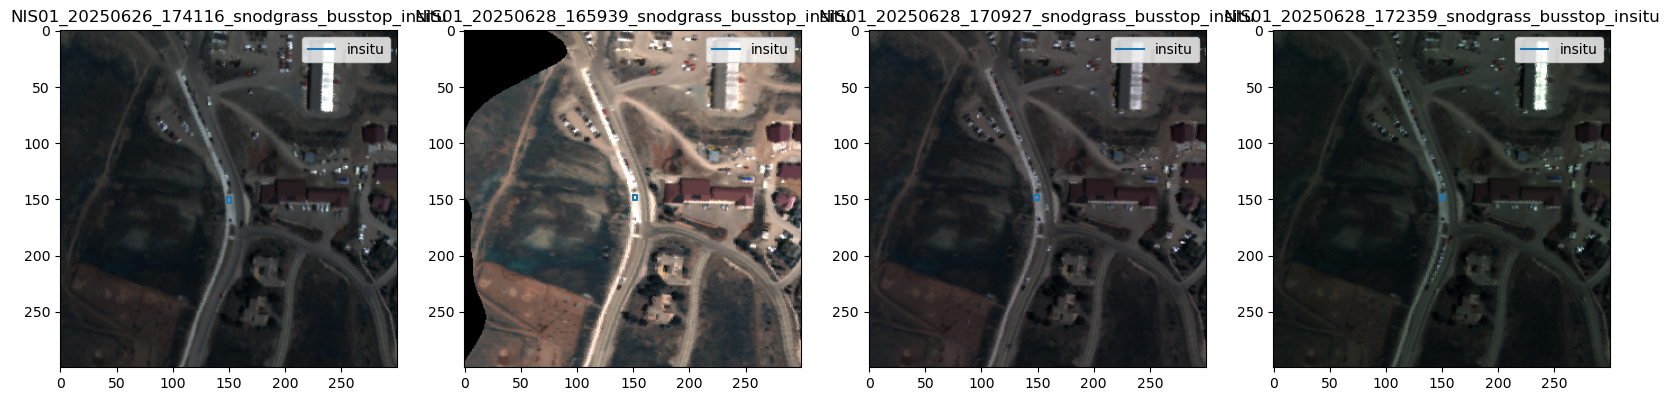

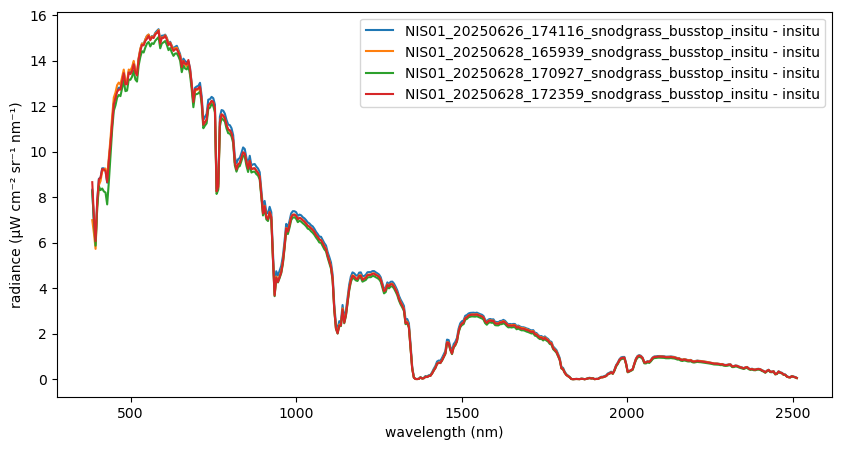

In [46]:
#viz

output_dir = 'rccs/subsets'

with open(os.path.join('rccs', 'single_pxs.pkl'), 'rb') as f:
    px = pickle.load(f)

with open(os.path.join('rccs', 'single_pxs_bboxes.pkl'), 'rb') as f:
    bboxes = pickle.load(f)

flights = list(px.keys())
flights = [x for x in flights if 'snodgrass' in x]

n_flights = len(flights)

fig, axs = plt.subplots(ncols=n_flights, figsize=(5*n_flights, 5))
for i in range(n_flights):
    flight = flights[i]
    fp = glob(os.path.join(output_dir, f'{flight}_rdn.hdr'))[0]
    wl = [float(x) for x in read_envi_header(fp)['wavelength']]
    rgb = envi.open(fp).open_memmap(interleave='bip')[:,:,np.array([60,40,30])].copy()
    axs[i].imshow(rgb / np.max(rgb, axis=(0, 1))*2)
    for k, (row1, row2, col1, col2) in bboxes[flight].items():
        x = [col1, col2, col2, col1, col1]
        y = [row1, row1, row2, row2, row1]
        axs[i].plot(x, y, label=k)
    axs[i].legend()
    axs[i].set_title(flight)
plt.show()

# plot radiance
fig = plt.figure(figsize=(10,5))
for f in flights:
    targets=px[f].keys()
    for k in targets:
        if k == 'insitu':
            plt.plot(wl, px[f][k]['rdn'], label=f'{f} - {k}')
plt.xlabel('wavelength (nm)')
plt.ylabel('radiance (μW cm⁻² sr⁻¹ nm⁻¹)')
plt.legend()
plt.show()